In [1]:
import os
import random

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA A100-PCIE-40GB


In [2]:
DATASET_PATH = "/fs/ess/PAS2699/osc_summer_camp_2026/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

VALID_DIR = os.path.join(DATASET_PATH, "valid")
TRAIN_DIR = os.path.join(DATASET_PATH, "train")

MODEL_PATH = "resnet18_plantdisease_part2_best.pth"

print("Valid exists:", os.path.exists(VALID_DIR))
print("Train exists:", os.path.exists(TRAIN_DIR))
print("Model exists:", os.path.exists(MODEL_PATH))

Valid exists: True
Train exists: True
Model exists: True


In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

valid_dataset = ImageFolder(root=VALID_DIR, transform=val_transform)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=1,
    pin_memory=True
)

CLASS_NAMES = valid_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print("Validation images:", len(valid_dataset))
print("Number of classes:", NUM_CLASSES)

print("\nClasses:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"{i:>2}: {cls}")

Validation images: 17572
Number of classes: 38

Classes:
 0: Apple___Apple_scab
 1: Apple___Black_rot
 2: Apple___Cedar_apple_rust
 3: Apple___healthy
 4: Blueberry___healthy
 5: Cherry_(including_sour)___Powdery_mildew
 6: Cherry_(including_sour)___healthy
 7: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 8: Corn_(maize)___Common_rust_
 9: Corn_(maize)___Northern_Leaf_Blight
10: Corn_(maize)___healthy
11: Grape___Black_rot
12: Grape___Esca_(Black_Measles)
13: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14: Grape___healthy
15: Orange___Haunglongbing_(Citrus_greening)
16: Peach___Bacterial_spot
17: Peach___healthy
18: Pepper,_bell___Bacterial_spot
19: Pepper,_bell___healthy
20: Potato___Early_blight
21: Potato___Late_blight
22: Potato___healthy
23: Raspberry___healthy
24: Soybean___healthy
25: Squash___Powdery_mildew
26: Strawberry___Leaf_scorch
27: Strawberry___healthy
28: Tomato___Bacterial_spot
29: Tomato___Early_blight
30: Tomato___Late_blight
31: Tomato___Leaf_Mold
32: Tomato_

In [6]:
# Build the same ResNet18 structure used in Part 2.
model = models.resnet18(weights=None)

# Replace final layer with plant disease output classes.
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# Load learned weights from Part 2.
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

# Move model to GPU/CPU and set evaluation mode.
model = model.to(device)
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [7]:
all_preds = []
all_labels = []
all_probs = []

print("Running model on validation images...")

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)

        # Raw model scores.
        outputs = model(images)

        # Convert raw scores to probabilities.
        probs = torch.softmax(outputs, dim=1)

        # Pick class with highest probability.
        predicted = probs.argmax(dim=1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

overall_acc = 100 * (all_preds == all_labels).mean()

print("Done.")
print(f"Overall validation accuracy: {overall_acc:.2f}%")

Running model on validation images...
Done.
Overall validation accuracy: 96.81%


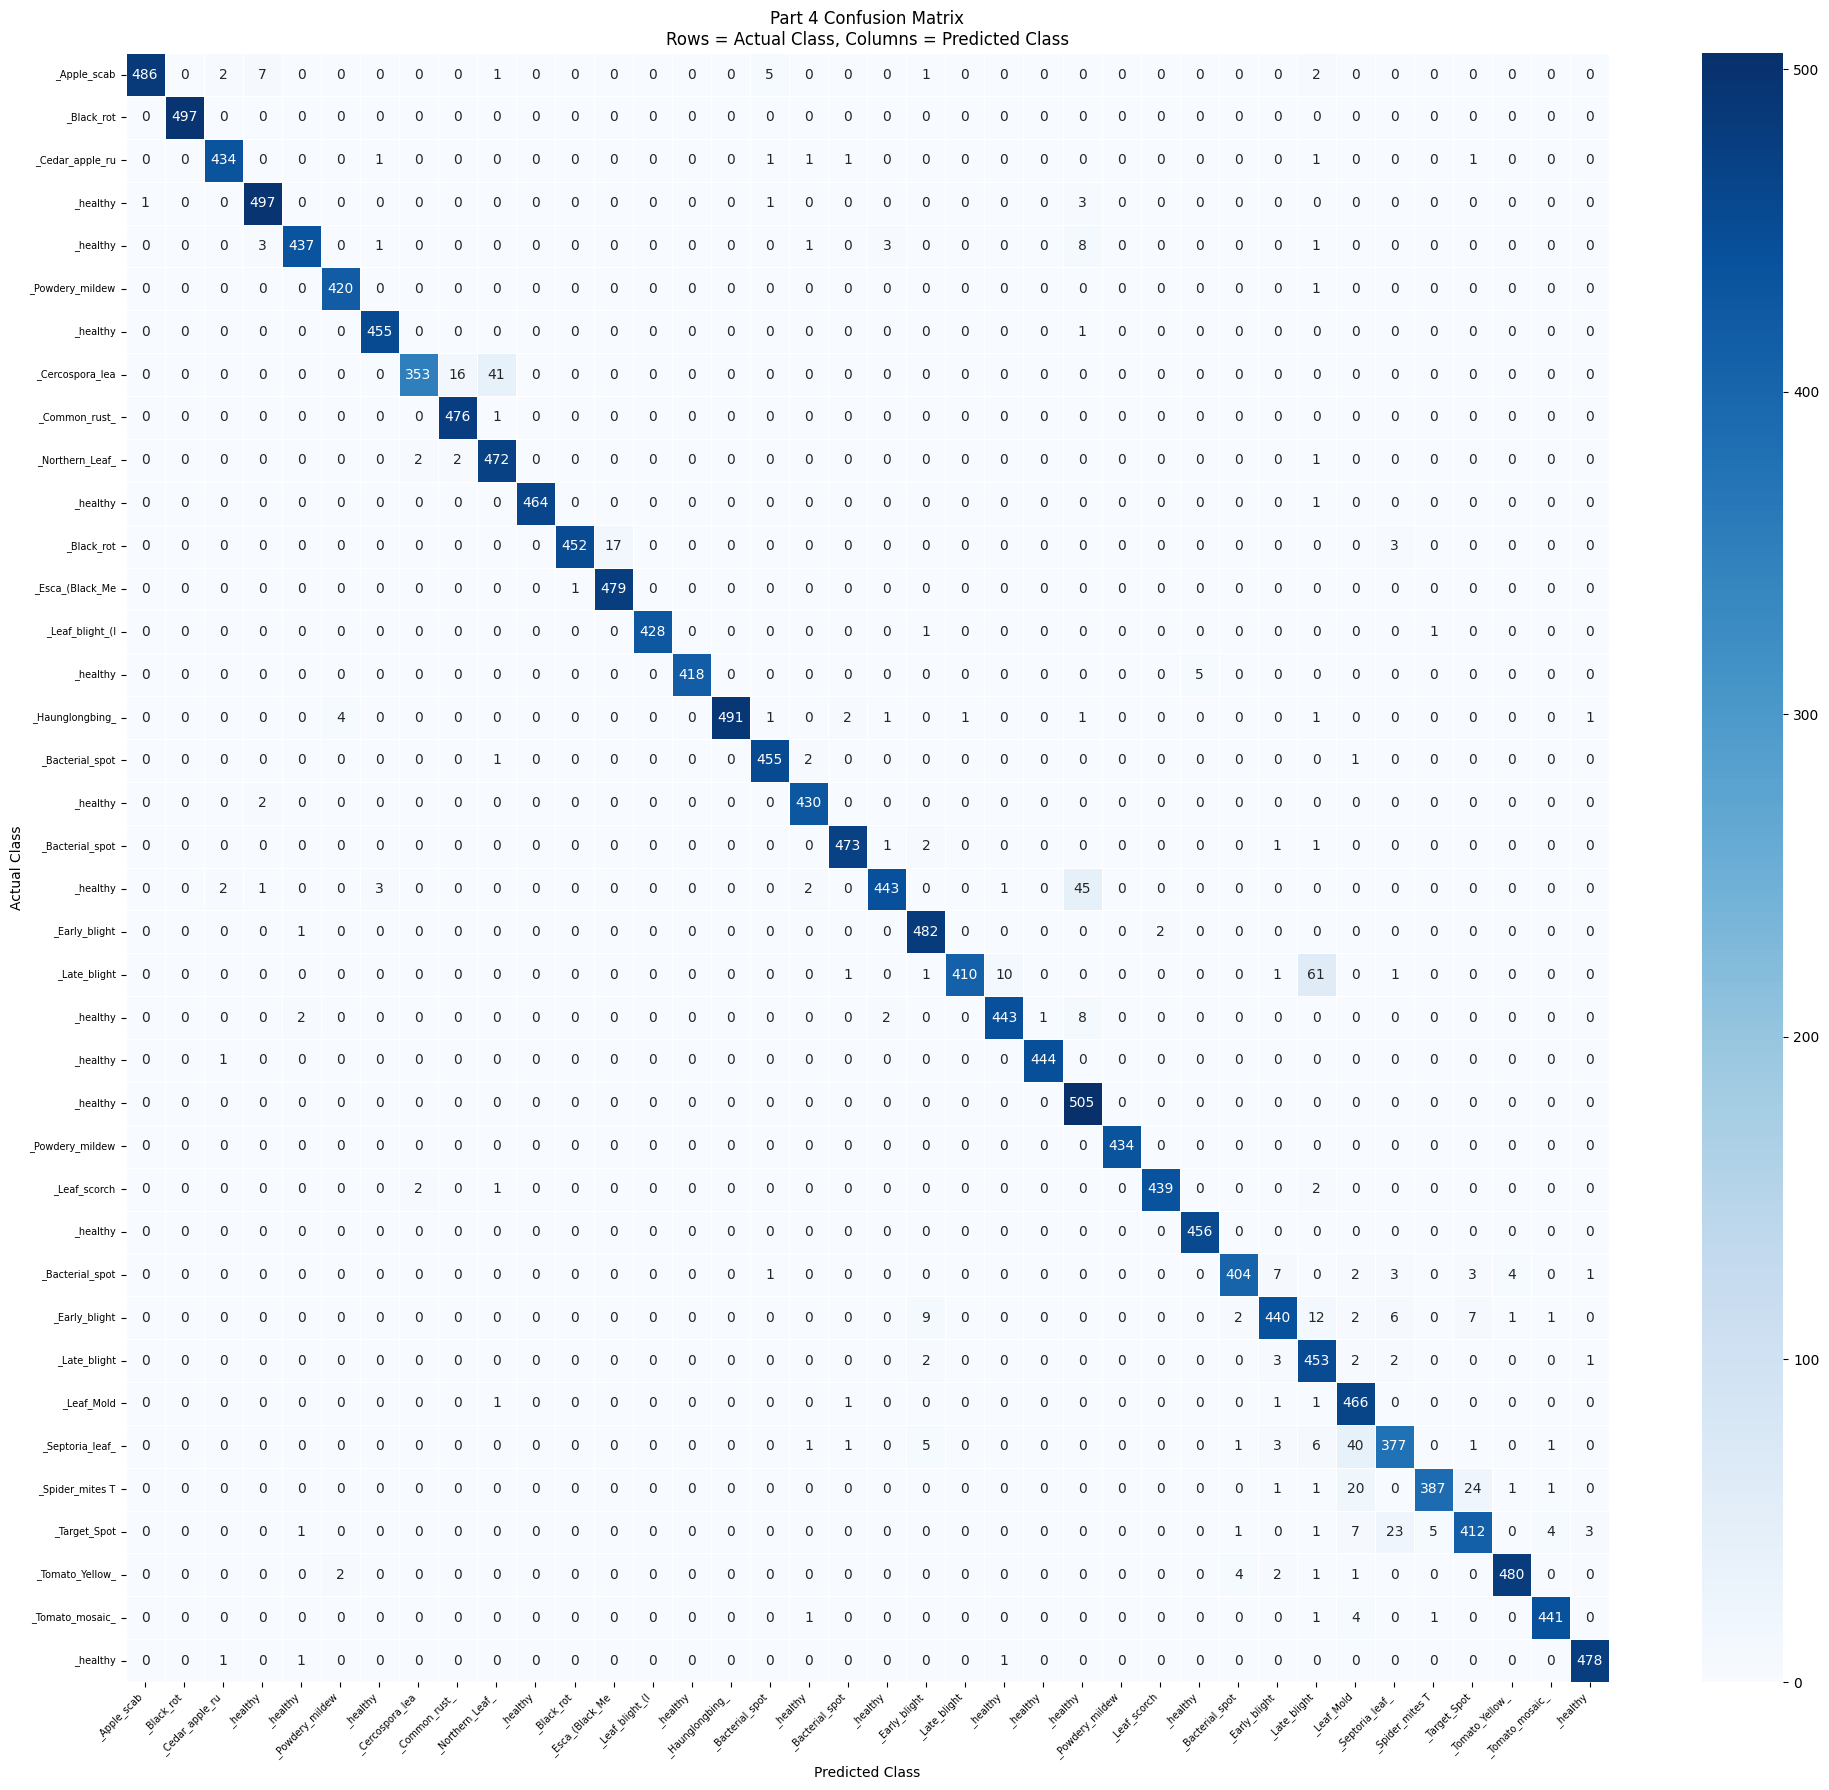

Saved: part4_confusion_matrix.png


In [8]:
cm = confusion_matrix(all_labels, all_preds)

# Shorter class names for chart labels.
short_names = [c.split("__")[-1][:15] for c in CLASS_NAMES]

plt.figure(figsize=(20, 18))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=short_names,
    yticklabels=short_names,
    linewidths=0.5
)

plt.title("Part 4 Confusion Matrix\nRows = Actual Class, Columns = Predicted Class")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig("part4_confusion_matrix.png", dpi=150)
plt.show()

print("Saved: part4_confusion_matrix.png")

In [9]:
per_class_acc = []

for i in range(NUM_CLASSES):
    mask = (all_labels == i)

    if mask.sum() > 0:
        acc = 100 * (all_preds[mask] == i).mean()
    else:
        acc = 0.0

    per_class_acc.append(acc)

sorted_indices = np.argsort(per_class_acc)

print("Top 5 easiest classes:")
for i in sorted_indices[-5:][::-1]:
    print(f"{CLASS_NAMES[i]:<50} {per_class_acc[i]:.2f}%")

print("\nBottom 5 hardest classes:")
for i in sorted_indices[:5]:
    print(f"{CLASS_NAMES[i]:<50} {per_class_acc[i]:.2f}%")

Top 5 easiest classes:
Strawberry___healthy                               100.00%
Apple___Black_rot                                  100.00%
Soybean___healthy                                  100.00%
Squash___Powdery_mildew                            100.00%
Grape___Esca_(Black_Measles)                       99.79%

Bottom 5 hardest classes:
Potato___Late_blight                               84.54%
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 86.10%
Tomato___Septoria_leaf_spot                        86.47%
Tomato___Spider_mites Two-spotted_spider_mite      88.97%
Pepper,_bell___healthy                             89.13%


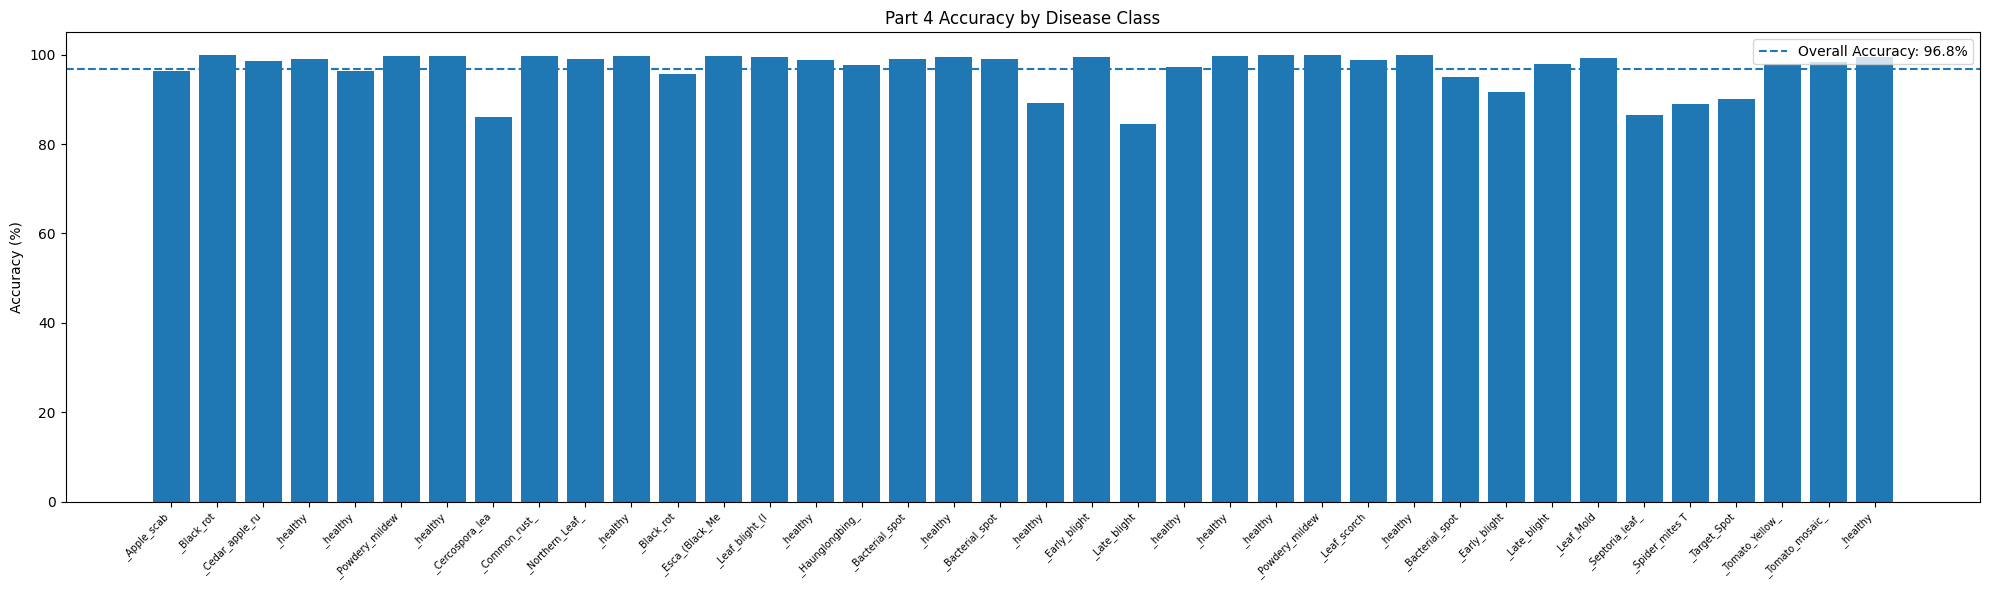

Saved: part4_class_accuracies.png


In [10]:
plt.figure(figsize=(20, 6))

plt.bar(range(NUM_CLASSES), per_class_acc)
plt.axhline(
    y=overall_acc,
    linestyle="--",
    label=f"Overall Accuracy: {overall_acc:.1f}%"
)

plt.xticks(range(NUM_CLASSES), short_names, rotation=45, ha="right", fontsize=7)
plt.ylabel("Accuracy (%)")
plt.title("Part 4 Accuracy by Disease Class")
plt.legend()
plt.tight_layout()
plt.savefig("part4_class_accuracies.png", dpi=150)
plt.show()

print("Saved: part4_class_accuracies.png")

In [12]:
def unnormalize(tensor):
    """
    Convert normalized image tensor back into displayable image format.
    """

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = tensor.cpu() * std + mean
    img = img.clamp(0, 1)

    # Convert from C x H x W to H x W x C for matplotlib.
    return img.permute(1, 2, 0).numpy()

In [13]:
def show_predictions(dataset, model, device, class_names, n=8, only_wrong=False):
    """
    Show random model predictions.
    If only_wrong=True, show only misclassified examples.
    """

    indices = list(range(len(dataset)))
    random.shuffle(indices)

    results = []

    for idx in indices:
        image, true_label = dataset[idx]
        image_batch = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_batch)
            probs = torch.softmax(output, dim=1)
            pred = probs.argmax(dim=1).item()
            conf = probs[0, pred].item() * 100

        is_wrong = (pred != true_label)

        if only_wrong and not is_wrong:
            continue

        results.append((image, true_label, pred, conf, is_wrong))

        if len(results) >= n:
            break

    if len(results) == 0:
        print("No examples found.")
        return

    cols = 4
    rows = int(np.ceil(len(results) / cols))

    title = "Wrong Predictions" if only_wrong else "Random Predictions"

    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for i, (image, true_lbl, pred_lbl, conf, wrong) in enumerate(results):
        ax = axes[i]
        ax.imshow(unnormalize(image))
        ax.axis("off")

        true_short = class_names[true_lbl].split("__")[-1]
        pred_short = class_names[pred_lbl].split("__")[-1]

        status = "WRONG" if wrong else "RIGHT"

        ax.set_title(
            f"{status}\nTrue: {true_short}\nPred: {pred_short}\nConf: {conf:.1f}%",
            fontsize=8
        )

    plt.tight_layout()
    filename = "part4_predictions_wrong.png" if only_wrong else "part4_predictions_random.png"
    plt.savefig(filename, dpi=150)
    plt.show()

    print("Saved:", filename)

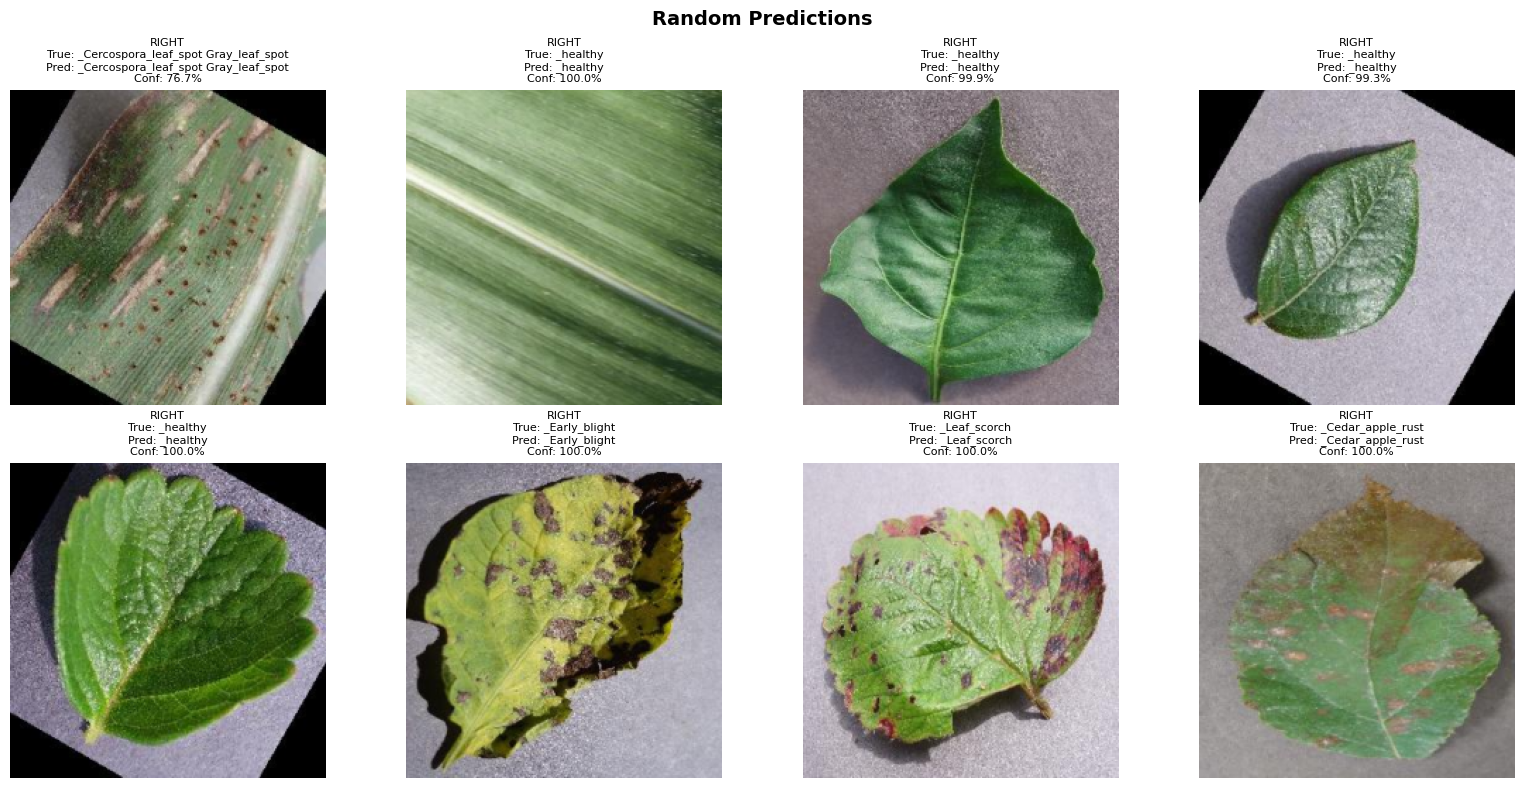

Saved: part4_predictions_random.png


In [14]:
show_predictions(
    dataset=valid_dataset,
    model=model,
    device=device,
    class_names=CLASS_NAMES,
    n=8,
    only_wrong=False
)

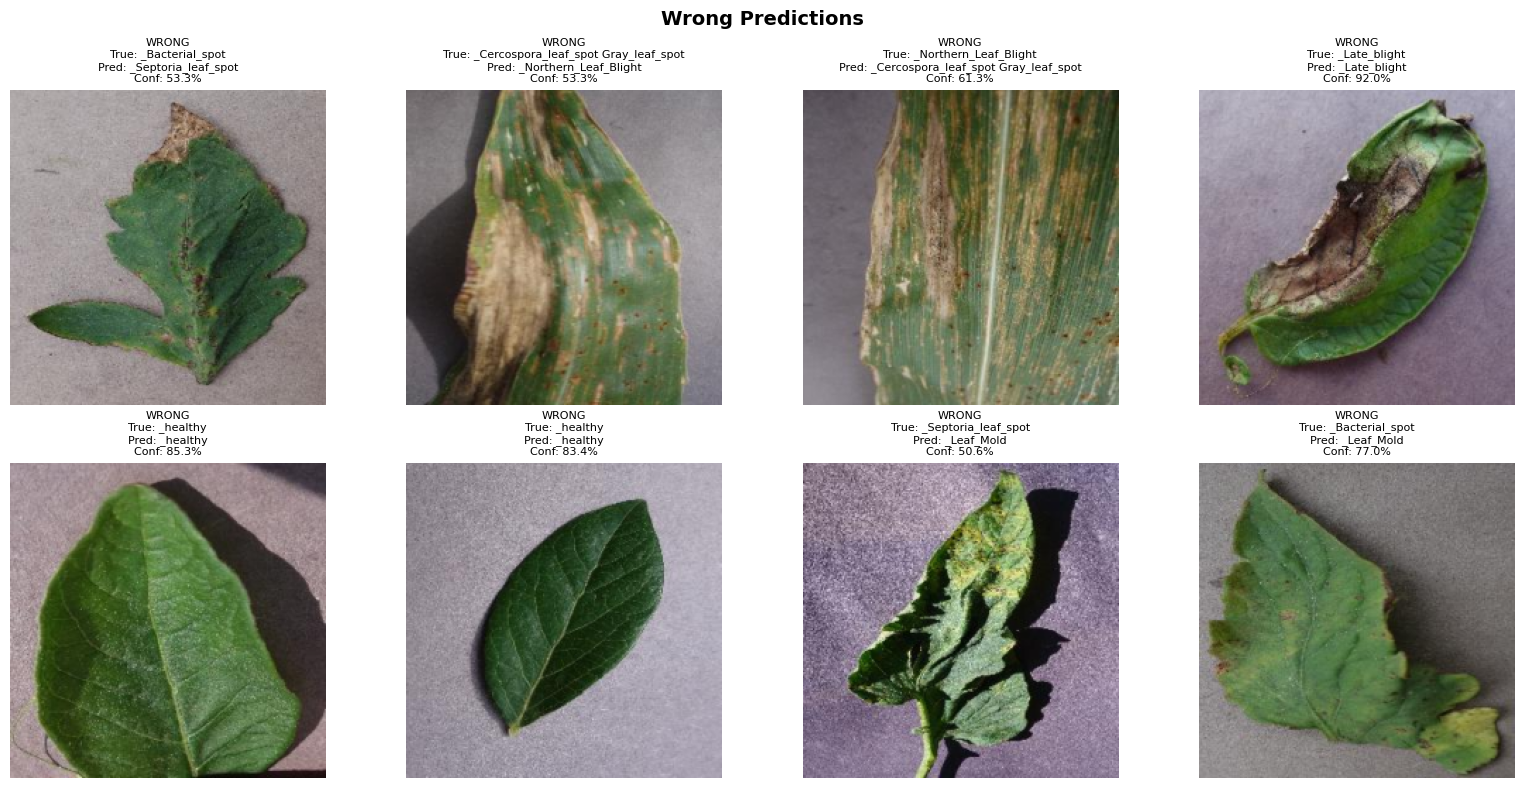

Saved: part4_predictions_wrong.png


In [15]:
show_predictions(
    dataset=valid_dataset,
    model=model,
    device=device,
    class_names=CLASS_NAMES,
    n=8,
    only_wrong=True
)

In [16]:
print("Classification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[c.split("__")[-1] for c in CLASS_NAMES],
        digits=2
    )
)

Classification Report:

                                       precision    recall  f1-score   support

                          _Apple_scab       1.00      0.96      0.98       504
                           _Black_rot       1.00      1.00      1.00       497
                    _Cedar_apple_rust       0.99      0.99      0.99       440
                             _healthy       0.97      0.99      0.98       502
                             _healthy       0.99      0.96      0.98       454
                      _Powdery_mildew       0.99      1.00      0.99       421
                             _healthy       0.99      1.00      0.99       456
 _Cercospora_leaf_spot Gray_leaf_spot       0.99      0.86      0.92       410
                        _Common_rust_       0.96      1.00      0.98       477
                _Northern_Leaf_Blight       0.91      0.99      0.95       477
                             _healthy       1.00      1.00      1.00       465
                           

In [17]:
files_to_check = [
    "part4_confusion_matrix.png",
    "part4_class_accuracies.png",
    "part4_predictions_random.png",
    "part4_predictions_wrong.png"
]

for f in files_to_check:
    print(f, "exists:", os.path.exists(f))

part4_confusion_matrix.png exists: True
part4_class_accuracies.png exists: True
part4_predictions_random.png exists: True
part4_predictions_wrong.png exists: True
